In [2]:
from google.colab import files

uploaded = files.upload()

Saving processed_cloud_traffic.csv to processed_cloud_traffic.csv


In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import joblib

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
# Load Dataset
df = pd.read_csv("processed_cloud_traffic.csv")

print(df.shape)

df.head()

(99976, 40)


,timestamp,request_count,active_users,cpu_usage,memory_usage,network_in,network_out,disk_io,response_time,server_instances,...,rolling_mean_12,rolling_std_12,rolling_max_12,rolling_min_12,traffic_growth_rate,request_velocity,traffic_momentum,cpu_memory_ratio,network_total,resource_pressure
0,2024-01-01 02:00:00,47.656311,295,60.552943,54.119293,127.468587,83.779346,53.431992,31.508014,14,...,54.634911,12.674836,73.893131,33.964223,-0.117869,-6.367775,-9.021658,1.098580,211.247933,39.890745
1,2024-01-01 02:05:00,50.959050,559,43.361569,30.886547,111.930504,92.446982,75.808958,30.306730,10,...,56.051147,10.993106,73.893131,37.746109,0.069303,3.302739,-6.998429,1.359870,204.377486,25.416038
2,2024-01-01 02:10:00,37.165827,343,47.021166,38.216049,100.778232,61.564165,34.701423,35.238940,11,...,53.934997,12.022291,73.893131,37.165827,-0.270673,-13.793223,-17.354812,1.199029,162.342397,31.079072
3,2024-01-01 02:15:00,65.366898,624,65.982443,55.459345,160.218212,132.495264,25.330902,49.986736,15,...,55.418400,12.260838,73.893131,37.165827,0.758790,28.201071,12.267298,1.168672,292.713476,43.147263
4,2024-01-01 02:20:00,39.477318,365,45.236018,37.351978,104.781733,71.488838,38.667893,65.298155,11,...,55.562667,12.042229,73.893131,37.165827,-0.396066,-25.889580,-9.630931,1.179496,176.270570,27.529332


In [5]:
# Features and Target
X = df.drop(columns=["timestamp", "request_count"])

y = df["request_count"]

In [6]:
# Time Series Split
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [7]:
# Train XGBoost
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [8]:
# Prediction
pred = model.predict(X_test)

In [9]:
# Evaluation
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("="*50)
print("XGBoost Performance")
print("="*50)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

XGBoost Performance
MAE  : 1.67
RMSE : 9.15
R²   : 0.9798


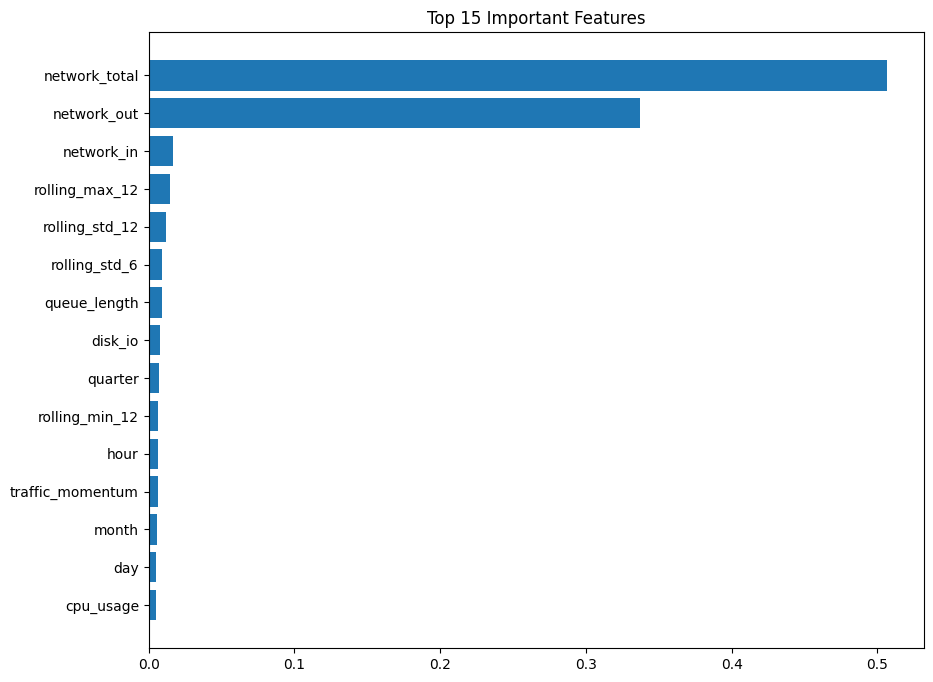

In [10]:
# Feature Importance
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [11]:
# Save Model
joblib.dump(model, "xgboost_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [12]:
# Download Model
files.download("xgboost_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
model.save_model("xgboost_model.json")

print("Both models saved successfully!")

Both models saved successfully!


In [15]:
from xgboost import XGBRegressor

model = XGBRegressor()
model.load_model("xgboost_model.json")

In [13]:
import xgboost
import sklearn
import joblib
import pandas

print("xgboost:", xgboost.__version__)
print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("pandas:", pandas.__version__)

xgboost: 3.3.0
sklearn: 1.6.1
joblib: 1.5.3
pandas: 2.2.2


In [17]:
!python --version

Python 3.12.13
